In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = '../google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'gdelt-analysis-494301'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [2]:
# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [
    '130', '131', '1311', '1312', '1313', '138', '139', 
    '140', '141', '1411', '1412', '1413', '142', '143', '144', '145', 
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    IsRootEvent,           # 뉴스 리드 문단에 등장하는 핵심 사건인가? (1 or 0)
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    ActionGeo_Type,        # 좌표의 해상도 (1:국가, 2:주, 3:도시, 4/5:정밀 랜드마크)
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401 
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
"""

# 2. 데이터 불러오기
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("데이터 불러오기 완료")
display(df.head())

Downloading: 100%|██████████|
데이터 불러오기 완료


,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20220612,1,202,-10.0,8,-6.225681,4,39.9044,116.391,https://focustaiwan.tw/society/202206120012
1,20241013,1,152,-7.2,2,-2.893868,4,39.9289,116.388,https://thesun.my/world-news/taiwan-on-alert-a...
2,20241013,1,152,-7.2,6,-2.977706,4,39.9289,116.388,https://thesun.my/world-news/taiwan-on-alert-a...
3,20220914,1,1312,-5.8,4,-5.436215,1,51.5000,10.500,https://www.jpost.com/international/article-71...
4,20220914,1,1312,-5.8,2,-5.770132,1,49.0000,32.000,https://www.shorenewsnetwork.com/2022/09/14/ex...


In [3]:
# 데이터의 기본 정보 요약
print("--- [데이터 구조 확인] ---")
print(df.info())

# 결측치(NaN) 확인 - 리포트 신뢰도와 직결
print("\n--- [결측치 비율 (%)] ---")
print(df.isnull().mean() * 100)

# 주요 수치 데이터의 기초 통계량 (평균, 최소, 최대, 4분위수)
print("\n--- [주요 수치 통계] ---")
display(df[['GoldsteinScale']].describe())

--- [데이터 구조 확인] ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56155 entries, 0 to 56154
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SQLDATE         56155 non-null  Int64  
 1   IsRootEvent     56155 non-null  Int64  
 2   EventCode       56155 non-null  object 
 3   GoldsteinScale  56155 non-null  float64
 4   NumMentions     56155 non-null  Int64  
 5   AvgTone         56155 non-null  float64
 6   ActionGeo_Type  56155 non-null  Int64  
 7   ActionGeo_Lat   56147 non-null  float64
 8   ActionGeo_Long  56147 non-null  float64
 9   SOURCEURL       56155 non-null  object 
dtypes: Int64(4), float64(4), object(2)
memory usage: 4.5+ MB
None

--- [결측치 비율 (%)] ---
SQLDATE           0.000000
IsRootEvent       0.000000
EventCode         0.000000
GoldsteinScale    0.000000
NumMentions       0.000000
AvgTone           0.000000
ActionGeo_Type    0.000000
ActionGeo_Lat     0.014246
ActionGeo_Long    0.014246

,GoldsteinScale
count,56155.000000
mean,-7.192120
std,2.216819
min,-10.000000
25%,-10.000000
50%,-7.200000
75%,-4.400000
max,-4.400000


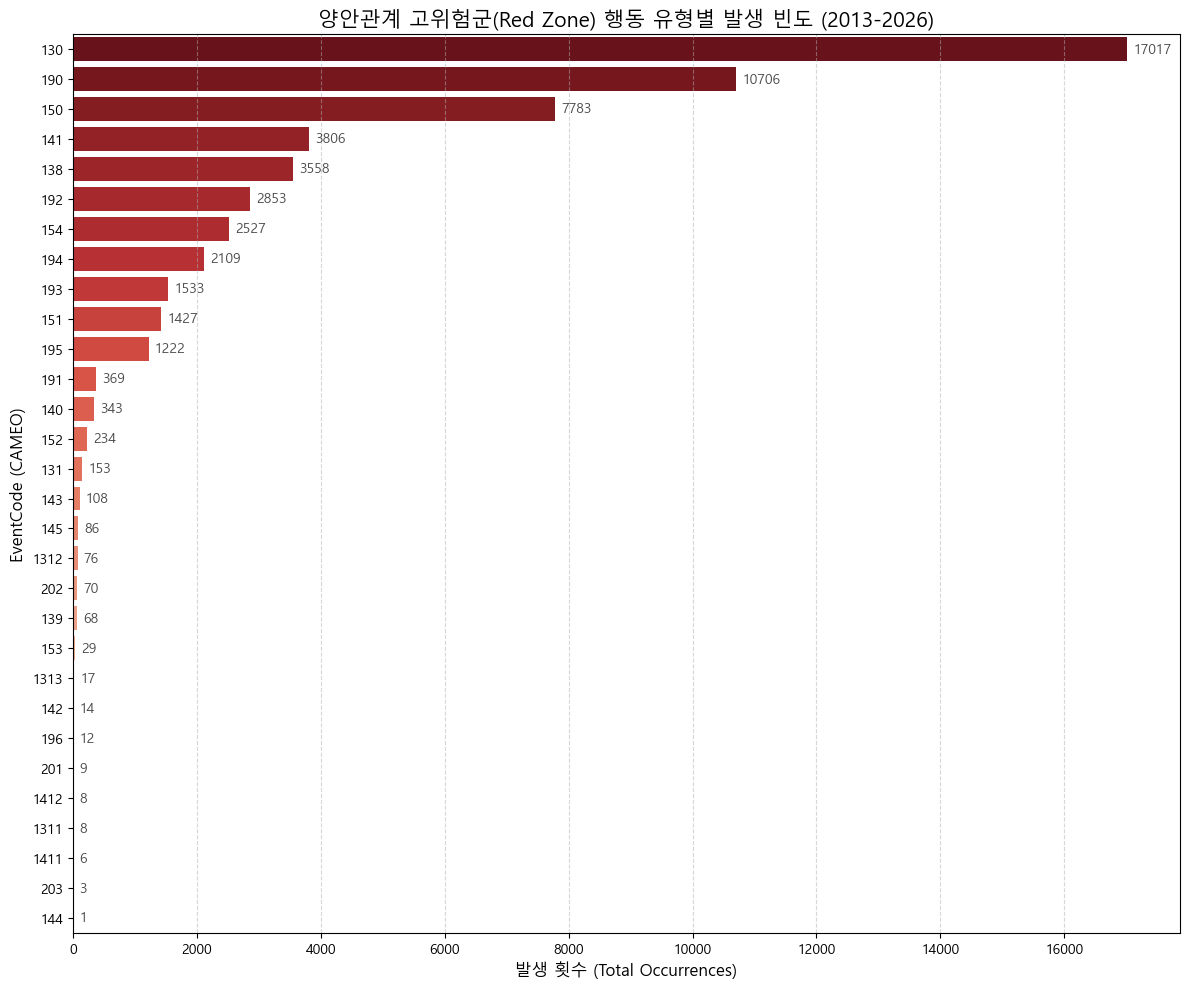

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 윈도우용 한글 폰트 및 마이너스 기호 깨짐 방지
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 1. EventCode별 데이터 빈도수 계산 및 정렬
event_counts = df['EventCode'].value_counts().reset_index()
event_counts.columns = ['EventCode', 'Count']
event_counts = event_counts.sort_values(by='Count', ascending=False)

# 2. 시각화 (가로 막대 그래프)
plt.figure(figsize=(12, 10))

sns.barplot(
    data=event_counts, 
    x='Count', 
    y='EventCode', 
    hue='EventCode',    # 색상 기준 변수 명시
    palette='Reds_r', 
    legend=False        # 불필요한 범례 숨김
)

plt.title('양안관계 고위험군(Red Zone) 행동 유형별 발생 빈도 (2013-2026)', fontsize=15)
plt.xlabel('발생 횟수 (Total Occurrences)', fontsize=12)
plt.ylabel('EventCode (CAMEO)', fontsize=12)

# 막대 끝에 실제 수치 텍스트 추가
for index, value in enumerate(event_counts['Count']):
    plt.text(value + 100, index, str(value), va='center', fontsize=10, alpha=0.7)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

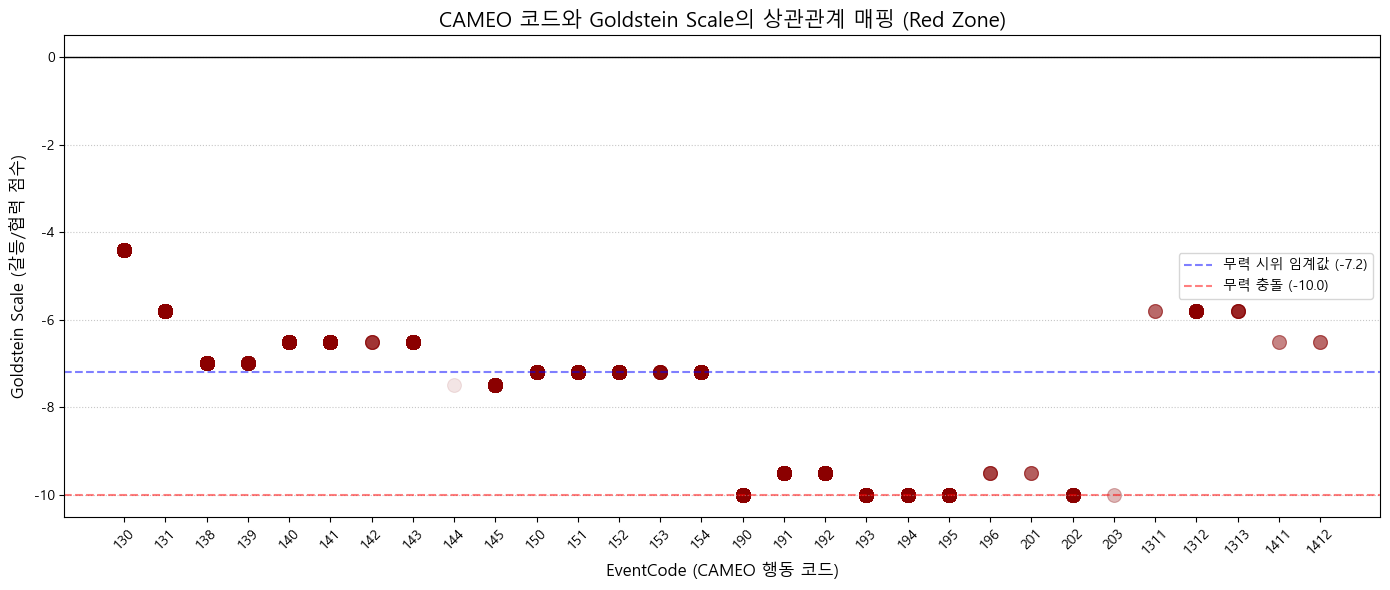

In [5]:
# EventCode를 오름차순으로 예쁘게 정렬하기 위한 작업
df_plot = df.copy()

# 정렬을 위해 임시로 숫자형으로 변환 (문자열 '190' -> 숫자 190)
df_plot['EventCode_Num'] = pd.to_numeric(df_plot['EventCode'], errors='coerce')
df_plot = df_plot.sort_values('EventCode_Num')

# 시각화 (산점도)
plt.figure(figsize=(14, 6))

# 투명도(alpha)를 주어 데이터가 얼마나 겹쳐 있는지 확인
sns.scatterplot(
    data=df_plot, 
    x='EventCode', 
    y='GoldsteinScale', 
    color='darkred', 
    s=100, 
    alpha=0.1, 
    edgecolor=None
)

plt.title('CAMEO 코드와 Goldstein Scale의 상관관계 매핑 (Red Zone)', fontsize=15)
plt.xlabel('EventCode (CAMEO 행동 코드)', fontsize=12)
plt.ylabel('Goldstein Scale (갈등/협력 점수)', fontsize=12)

# 가독성을 위해 기준선 추가
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(-7.2, color='blue', linestyle='--', alpha=0.5, label='무력 시위 임계값 (-7.2)')
plt.axhline(-10.0, color='red', linestyle='--', alpha=0.5, label='무력 충돌 (-10.0)')

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

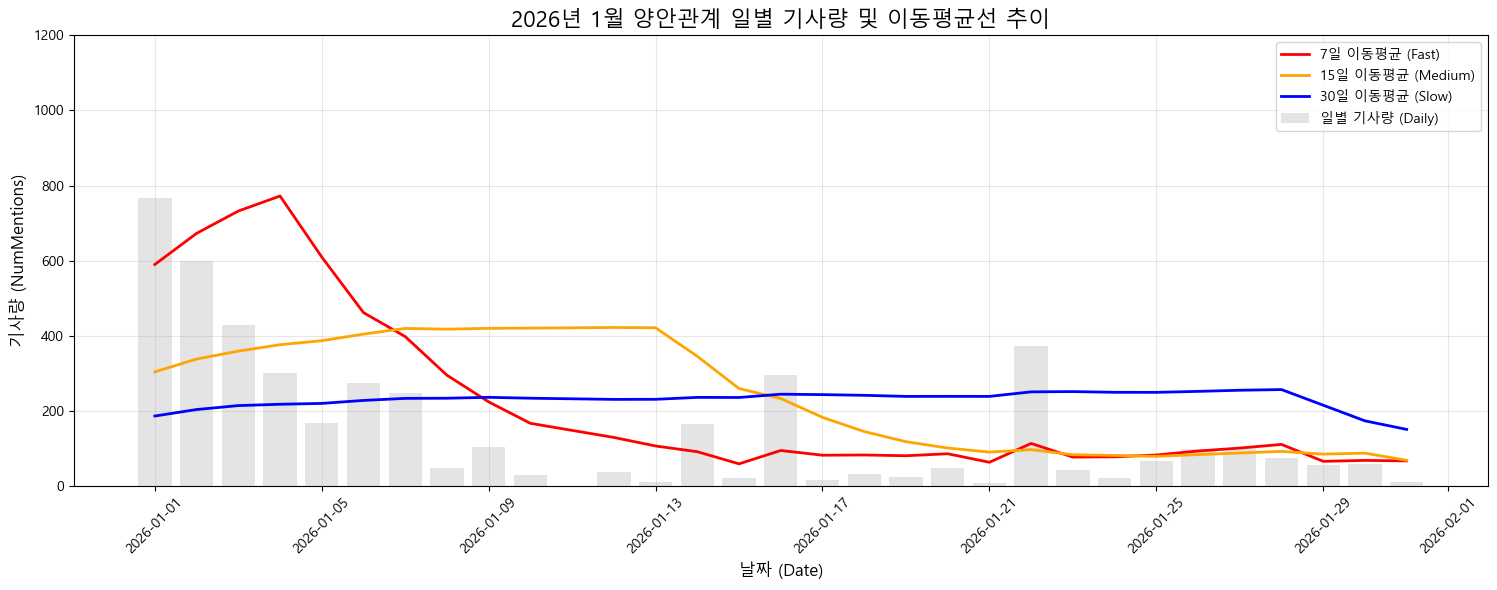

In [6]:
# 1. 날짜 데이터 형식 변환
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d', errors='coerce')

# 2. 일별 총 기사량(NumMentions) 집계
daily_volume = df.groupby('SQLDATE')['NumMentions'].sum().to_frame()

# 3. 7일, 15일, 30일 이동평균선(Rolling Mean) 계산
daily_volume['MA_7'] = daily_volume['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_volume['MA_15'] = daily_volume['NumMentions'].rolling(window=15, min_periods=1).mean()
daily_volume['MA_30'] = daily_volume['NumMentions'].rolling(window=30, min_periods=1).mean()

# 4. 2026년 1월 데이터 필터링 (Zoom-in)
start_date = '2026-01-01'
end_date = '2026-01-31'
mask = (daily_volume.index >= start_date) & (daily_volume.index <= end_date)
zoom_df = daily_volume.loc[mask]

# 5. 시각화 진행
plt.figure(figsize=(15, 6))

# 원본 일별 기사량은 배경에 옅은 막대그래프로 배치
plt.bar(zoom_df.index, zoom_df['NumMentions'], color='lightgray', alpha=0.6, label='일별 기사량 (Daily)')

# 3가지 이동평균선 그리기
plt.plot(zoom_df.index, zoom_df['MA_7'], color='red', linewidth=2, label='7일 이동평균 (Fast)')
plt.plot(zoom_df.index, zoom_df['MA_15'], color='orange', linewidth=2, label='15일 이동평균 (Medium)')
plt.plot(zoom_df.index, zoom_df['MA_30'], color='blue', linewidth=2, label='30일 이동평균 (Slow)')

# 그래프 타이틀 및 라벨 설정
plt.title('2026년 1월 양안관계 일별 기사량 및 이동평균선 추이', fontsize=16)
plt.xlabel('날짜 (Date)', fontsize=12)
plt.ylabel('기사량 (NumMentions)', fontsize=12)

# 범례 및 그리드 표시
plt.legend()
plt.grid(True, alpha=0.3)

# x축 날짜 글씨가 겹치지 않도록 45도 회전
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.ylim(0, 1200)
plt.show()

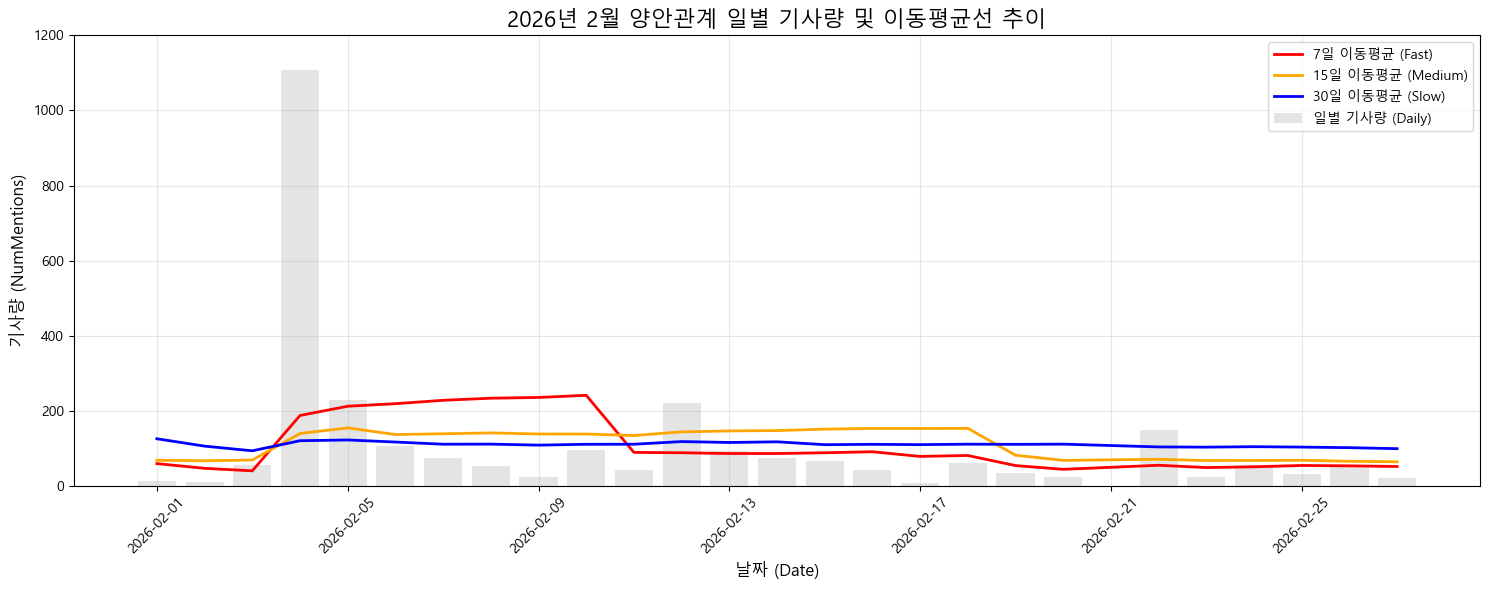

In [7]:
# 1. 날짜 데이터 형식 변환
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d', errors='coerce')

# 2. 일별 총 기사량(NumMentions) 집계
daily_volume = df.groupby('SQLDATE')['NumMentions'].sum().to_frame()

# 3. 7일, 15일, 30일 이동평균선(Rolling Mean) 계산
daily_volume['MA_7'] = daily_volume['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_volume['MA_15'] = daily_volume['NumMentions'].rolling(window=15, min_periods=1).mean()
daily_volume['MA_30'] = daily_volume['NumMentions'].rolling(window=30, min_periods=1).mean()

# 4. 2026년 1월 데이터 필터링 (Zoom-in)
start_date = '2026-02-01'
end_date = '2026-02-28'
mask = (daily_volume.index >= start_date) & (daily_volume.index <= end_date)
zoom_df = daily_volume.loc[mask]

# 5. 시각화 진행
plt.figure(figsize=(15, 6))

# 원본 일별 기사량은 배경에 옅은 막대그래프로 배치
plt.bar(zoom_df.index, zoom_df['NumMentions'], color='lightgray', alpha=0.6, label='일별 기사량 (Daily)')

# 3가지 이동평균선 그리기
plt.plot(zoom_df.index, zoom_df['MA_7'], color='red', linewidth=2, label='7일 이동평균 (Fast)')
plt.plot(zoom_df.index, zoom_df['MA_15'], color='orange', linewidth=2, label='15일 이동평균 (Medium)')
plt.plot(zoom_df.index, zoom_df['MA_30'], color='blue', linewidth=2, label='30일 이동평균 (Slow)')

# 그래프 타이틀 및 라벨 설정
plt.title('2026년 2월 양안관계 일별 기사량 및 이동평균선 추이', fontsize=16)
plt.xlabel('날짜 (Date)', fontsize=12)
plt.ylabel('기사량 (NumMentions)', fontsize=12)

# 범례 및 그리드 표시
plt.legend()
plt.grid(True, alpha=0.3)

# x축 날짜 글씨가 겹치지 않도록 45도 회전
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.ylim(0, 1200)
plt.show()

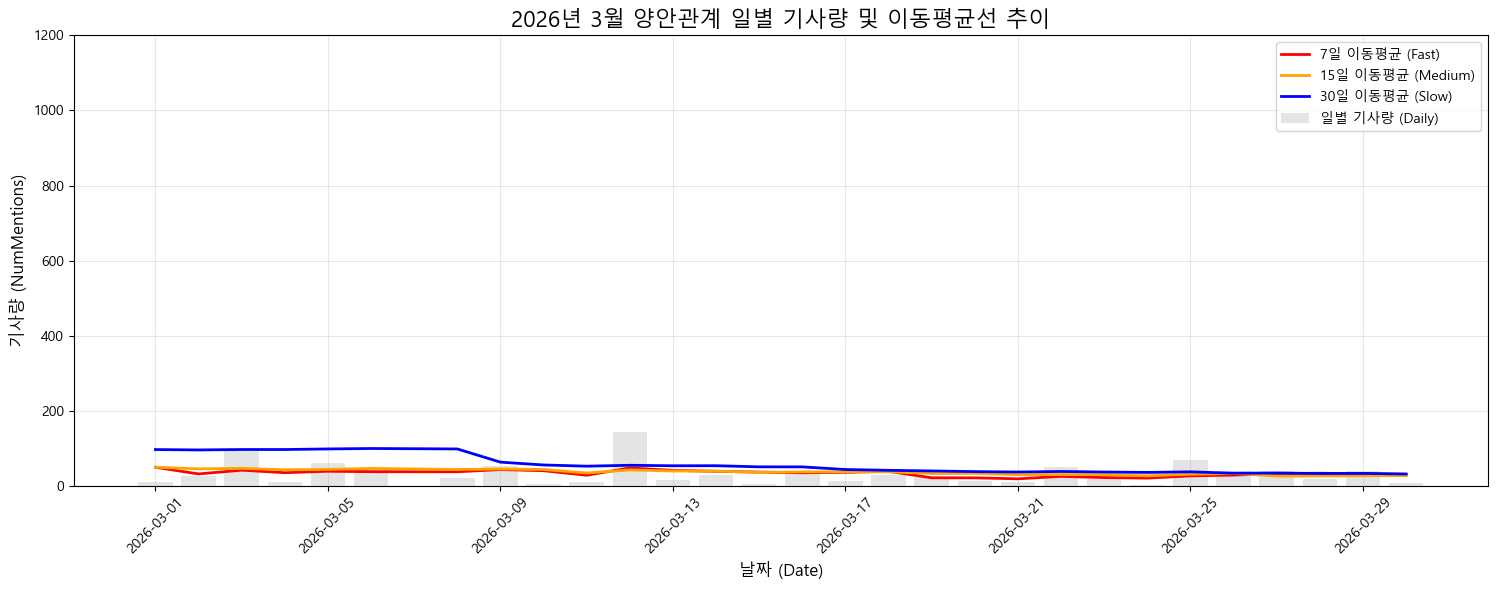

In [8]:
# 1. 날짜 데이터 형식 변환
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d', errors='coerce')

# 2. 일별 총 기사량(NumMentions) 집계
daily_volume = df.groupby('SQLDATE')['NumMentions'].sum().to_frame()

# 3. 7일, 15일, 30일 이동평균선(Rolling Mean) 계산
daily_volume['MA_7'] = daily_volume['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_volume['MA_15'] = daily_volume['NumMentions'].rolling(window=15, min_periods=1).mean()
daily_volume['MA_30'] = daily_volume['NumMentions'].rolling(window=30, min_periods=1).mean()

# 4. 2026년 1월 데이터 필터링 (Zoom-in)
start_date = '2026-03-01'
end_date = '2026-03-31'
mask = (daily_volume.index >= start_date) & (daily_volume.index <= end_date)
zoom_df = daily_volume.loc[mask]

# 5. 시각화 진행
plt.figure(figsize=(15, 6))

# 원본 일별 기사량은 배경에 옅은 막대그래프로 배치
plt.bar(zoom_df.index, zoom_df['NumMentions'], color='lightgray', alpha=0.6, label='일별 기사량 (Daily)')

# 3가지 이동평균선 그리기
plt.plot(zoom_df.index, zoom_df['MA_7'], color='red', linewidth=2, label='7일 이동평균 (Fast)')
plt.plot(zoom_df.index, zoom_df['MA_15'], color='orange', linewidth=2, label='15일 이동평균 (Medium)')
plt.plot(zoom_df.index, zoom_df['MA_30'], color='blue', linewidth=2, label='30일 이동평균 (Slow)')

# 그래프 타이틀 및 라벨 설정
plt.title('2026년 3월 양안관계 일별 기사량 및 이동평균선 추이', fontsize=16)
plt.xlabel('날짜 (Date)', fontsize=12)
plt.ylabel('기사량 (NumMentions)', fontsize=12)

# 범례 및 그리드 표시
plt.legend()
plt.grid(True, alpha=0.3)

# x축 날짜 글씨가 겹치지 않도록 45도 회전
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.ylim(0, 1200)
plt.show()

--- [이동평균선 돌파 일수 요약] ---


,기준선 (Baseline),돌파 일수 (Days)
0,7일선 초과 (단기),1480
1,15일선 초과 (중기),1284
2,30일선 초과 (장기),1174


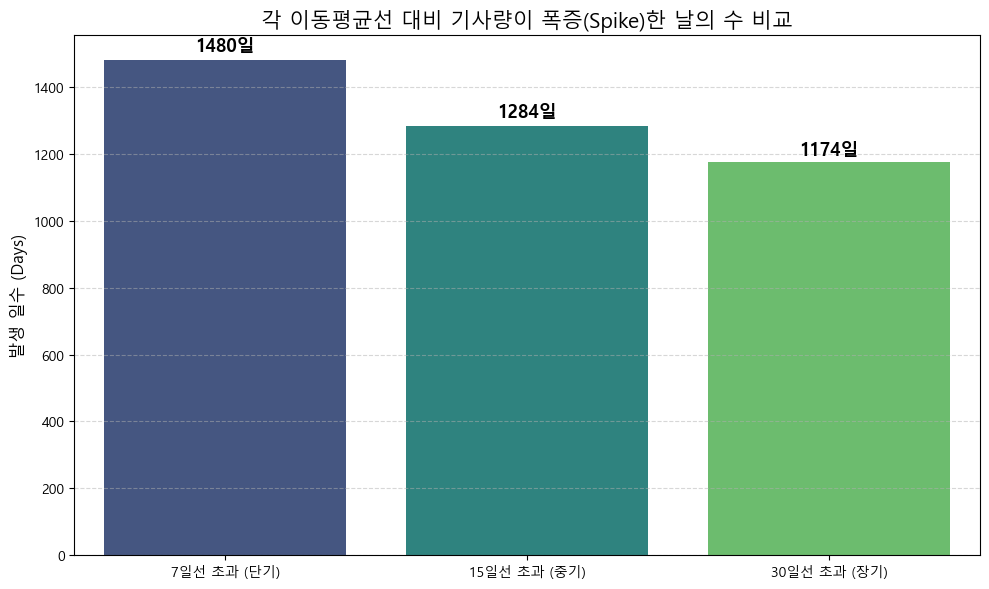

In [9]:
# 1. 각 이동평균선보다 당일 기사량이 더 많은 날(True)의 개수(sum)를 계산
# (조건식이 True이면 1, False이면 0이 되므로 sum()을 쓰면 일수가 나옵니다)
spike_7d = (daily_volume['NumMentions'] > daily_volume['MA_7']).sum()
spike_15d = (daily_volume['NumMentions'] > daily_volume['MA_15']).sum()
spike_30d = (daily_volume['NumMentions'] > daily_volume['MA_30']).sum()

# 2. 결과를 보기 쉽게 데이터프레임으로 정리
spike_counts = pd.DataFrame({
    '기준선 (Baseline)': ['7일선 초과 (단기)', '15일선 초과 (중기)', '30일선 초과 (장기)'],
    '돌파 일수 (Days)': [spike_7d, spike_15d, spike_30d]
})

print("--- [이동평균선 돌파 일수 요약] ---")
display(spike_counts)

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))

# 최신 Seaborn 문법 (hue 적용, 범례 숨김)
sns.barplot(
    data=spike_counts, 
    x='기준선 (Baseline)', 
    y='돌파 일수 (Days)', 
    hue='기준선 (Baseline)', 
    palette='viridis', 
    legend=False
)

plt.title('각 이동평균선 대비 기사량이 폭증(Spike)한 날의 수 비교', fontsize=15)
plt.ylabel('발생 일수 (Days)', fontsize=12)
plt.xlabel('')

# 막대 위에 실제 수치(일수) 텍스트 추가
for index, value in enumerate(spike_counts['돌파 일수 (Days)']):
    plt.text(index, value + (value * 0.01), f'{value}일', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

--- [IsRootEvent 발생 건수] ---
IsRootEvent
1    30559
0    25596
Name: count, dtype: Int64

--- [IsRootEvent 차지 비율 (%)] ---
IsRootEvent
1    54.42
0    45.58
Name: proportion, dtype: Float64


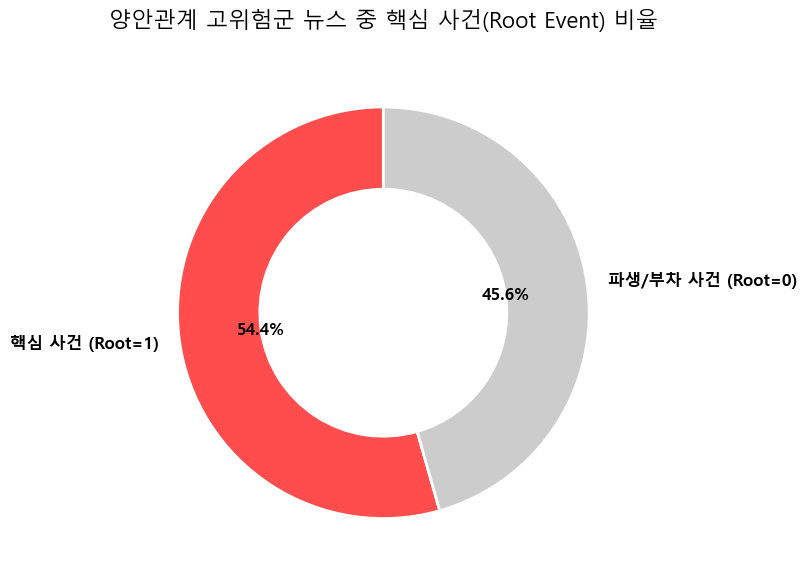

In [10]:
# 1. IsRootEvent 개수 및 비율(%) 계산
root_counts = df['IsRootEvent'].value_counts()
root_ratio = df['IsRootEvent'].value_counts(normalize=True) * 100

print("--- [IsRootEvent 발생 건수] ---")
print(root_counts)
print("\n--- [IsRootEvent 차지 비율 (%)] ---")
print(root_ratio.round(2))

# 2. 결과 시각화 (도넛 차트)
plt.figure(figsize=(8, 8))

# 인덱스(1 또는 0)에 맞춰 라벨 자동 생성
labels = ['핵심 사건 (Root=1)' if idx == 1 else '파생/부차 사건 (Root=0)' for idx in root_counts.index]
colors = ['#ff4d4d' if idx == 1 else '#cccccc' for idx in root_counts.index]

# 파이 차트를 그리고, 가운데를 뚫어서 도넛 모양으로 만듦 (wedgeprops 사용)
plt.pie(
    root_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)

plt.title('양안관계 고위험군 뉴스 중 핵심 사건(Root Event) 비율', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

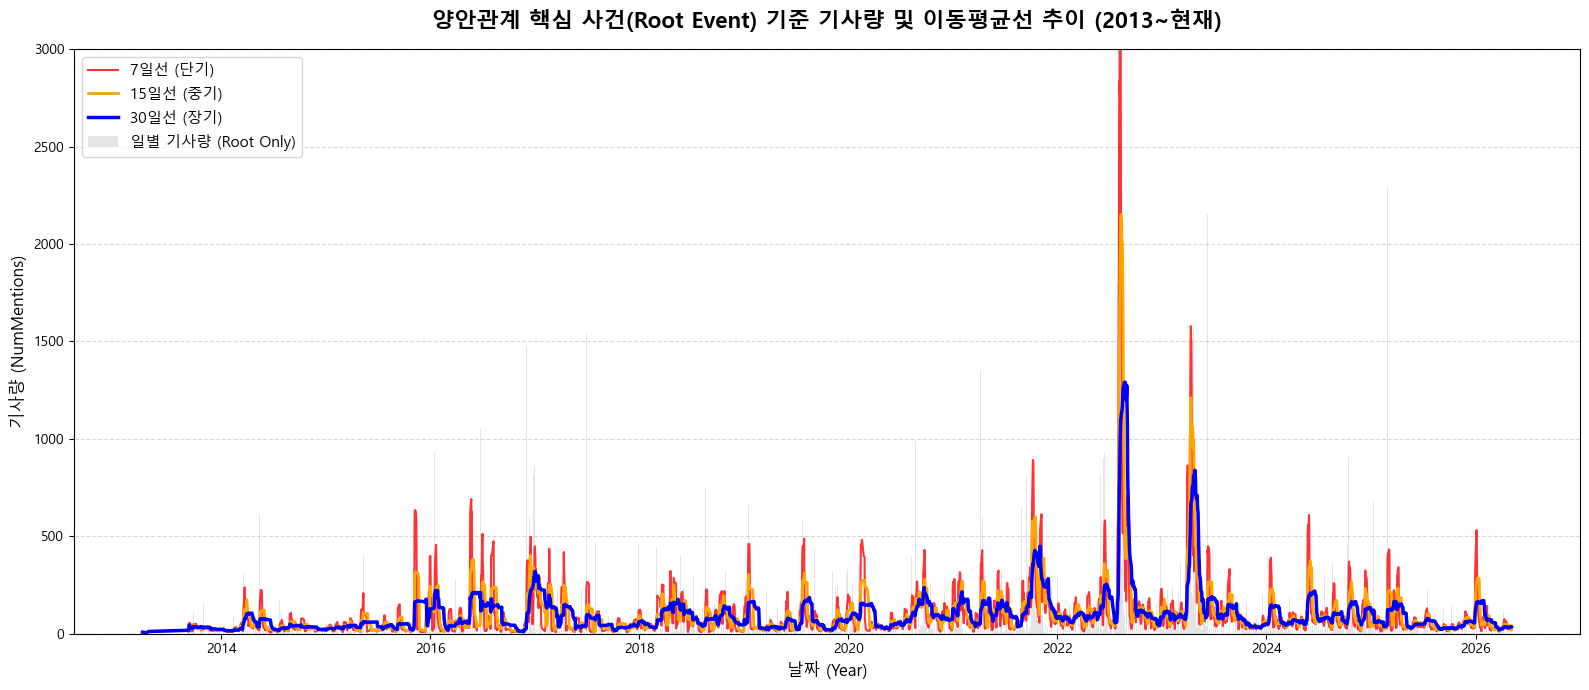

In [11]:
# 1. 핵심 사건(IsRootEvent == 1)만 필터링
df_root = df[df['IsRootEvent'] == 1].copy()

# 2. 날짜별 총 기사량(NumMentions) 집계
daily_root_volume = df_root.groupby('SQLDATE')['NumMentions'].sum().to_frame()

# 3. 이동평균선 계산 (7일, 15일, 30일)
daily_root_volume['MA_7'] = daily_root_volume['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_root_volume['MA_15'] = daily_root_volume['NumMentions'].rolling(window=15, min_periods=1).mean()
daily_root_volume['MA_30'] = daily_root_volume['NumMentions'].rolling(window=30, min_periods=1).mean()

# 4. 시각화 진행 (전체 기간)
plt.figure(figsize=(16, 7))

# 원본 일별 기사량 (회색 막대)
plt.bar(daily_root_volume.index, daily_root_volume['NumMentions'], color='lightgray', alpha=0.6, label='일별 기사량 (Root Only)')

# 이동평균선 그리기
plt.plot(daily_root_volume.index, daily_root_volume['MA_7'], color='red', linewidth=1.5, alpha=0.8, label='7일선 (단기)')
plt.plot(daily_root_volume.index, daily_root_volume['MA_15'], color='orange', linewidth=2, label='15일선 (중기)')
plt.plot(daily_root_volume.index, daily_root_volume['MA_30'], color='blue', linewidth=2.5, label='30일선 (장기)')

# 그래프 꾸미기
plt.title('양안관계 핵심 사건(Root Event) 기준 기사량 및 이동평균선 추이 (2013~현재)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('날짜 (Year)', fontsize=12)
plt.ylabel('기사량 (NumMentions)', fontsize=12)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 출력
plt.ylim(0, 3000)
plt.show()

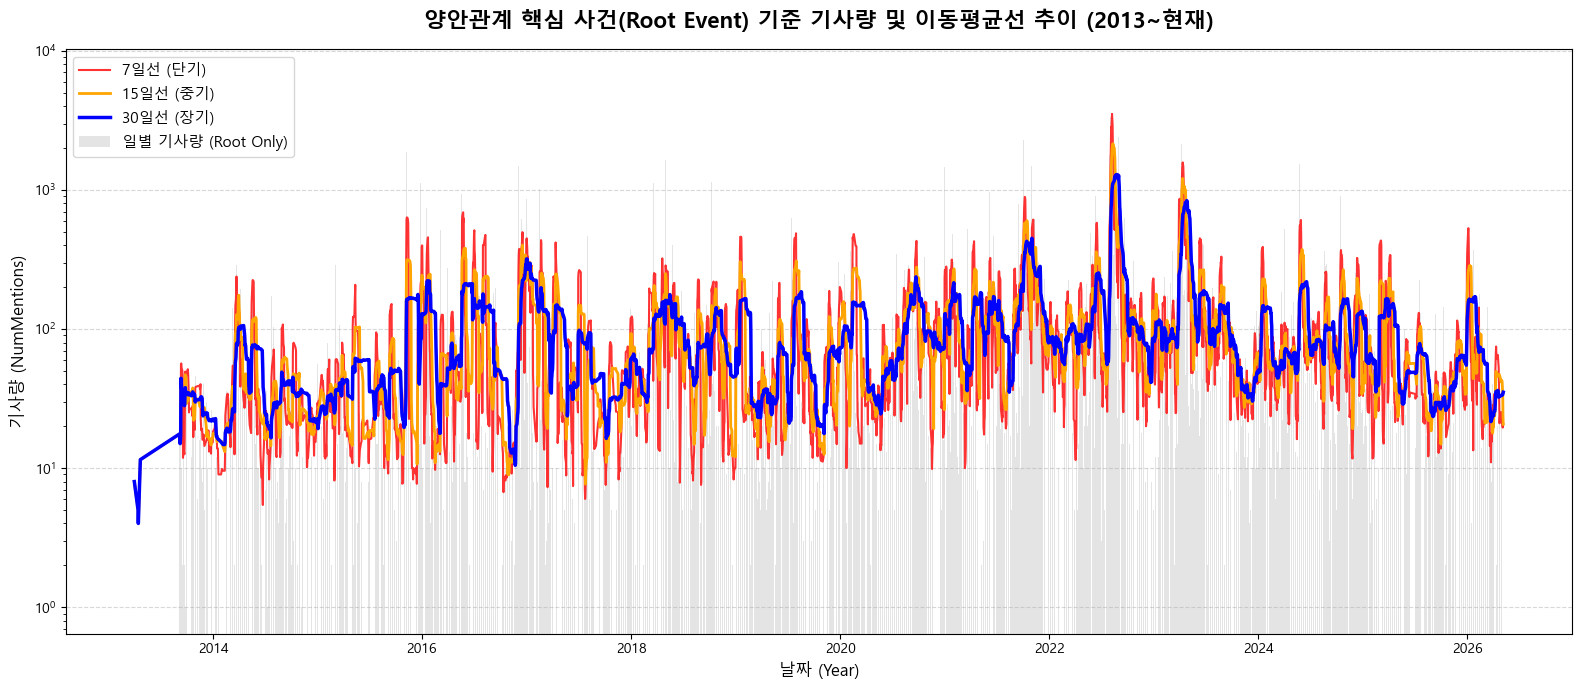

In [12]:
# 1. 핵심 사건(IsRootEvent == 1)만 필터링
df_root = df[df['IsRootEvent'] == 1].copy()

# 2. 날짜별 총 기사량(NumMentions) 집계
daily_root_volume = df_root.groupby('SQLDATE')['NumMentions'].sum().to_frame()

# 3. 이동평균선 계산 (7일, 15일, 30일)
daily_root_volume['MA_7'] = daily_root_volume['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_root_volume['MA_15'] = daily_root_volume['NumMentions'].rolling(window=15, min_periods=1).mean()
daily_root_volume['MA_30'] = daily_root_volume['NumMentions'].rolling(window=30, min_periods=1).mean()

# 4. 시각화 진행 (전체 기간)
plt.figure(figsize=(16, 7))

# 원본 일별 기사량 (회색 막대)
plt.bar(daily_root_volume.index, daily_root_volume['NumMentions'], color='lightgray', alpha=0.6, label='일별 기사량 (Root Only)')

# 이동평균선 그리기
plt.plot(daily_root_volume.index, daily_root_volume['MA_7'], color='red', linewidth=1.5, alpha=0.8, label='7일선 (단기)')
plt.plot(daily_root_volume.index, daily_root_volume['MA_15'], color='orange', linewidth=2, label='15일선 (중기)')
plt.plot(daily_root_volume.index, daily_root_volume['MA_30'], color='blue', linewidth=2.5, label='30일선 (장기)')

# 그래프 꾸미기
plt.title('양안관계 핵심 사건(Root Event) 기준 기사량 및 이동평균선 추이 (2013~현재)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('날짜 (Year)', fontsize=12)
plt.ylabel('기사량 (NumMentions)', fontsize=12)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 출력
plt.yscale('log')
plt.show()

In [13]:
# 1. 핵심 사건 기준: 각 이동평균선을 돌파한 일수(Days) 계산
spike_7d_root = (daily_root_volume['NumMentions'] > daily_root_volume['MA_7']).sum()
spike_15d_root = (daily_root_volume['NumMentions'] > daily_root_volume['MA_15']).sum()
spike_30d_root = (daily_root_volume['NumMentions'] > daily_root_volume['MA_30']).sum()

# 데이터프레임으로 정리
spike_counts_root = pd.DataFrame({
    '기준선 (Baseline)': ['7일선 초과 (단기)', '15일선 초과 (중기)', '30일선 초과 (장기)'],
    '돌파 일수 (Days)': [spike_7d_root, spike_15d_root, spike_30d_root]
})

print("--- 핵심 사건(Root=1) 기준: 전체 기간 이동평균선 돌파 일수 ---")
display(spike_counts_root)


# 2. 핵심 사건 기준: 기사량이 가장 많았던 'Top 10 위기 날짜' 추출
# NumMentions(기사량) 기준으로 내림차순 정렬하여 상위 10개만 뽑습니다.
top_10_days = daily_root_volume.sort_values(by='NumMentions', ascending=False).head(10)

# 소수점 아래가 너무 길게 나오는 것을 방지하기 위해 반올림
top_10_days = top_10_days.round(1)

print("\n--- 🚨 핵심 사건(Root=1) 기준: 기사량 폭증 역대 Top 10 날짜 ---")
display(top_10_days[['NumMentions', 'MA_7', 'MA_15', 'MA_30']])

--- 핵심 사건(Root=1) 기준: 전체 기간 이동평균선 돌파 일수 ---


,기준선 (Baseline),돌파 일수 (Days)
0,7일선 초과 (단기),1234
1,15일선 초과 (중기),1082
2,30일선 초과 (장기),956



--- 🚨 핵심 사건(Root=1) 기준: 기사량 폭증 역대 Top 10 날짜 ---


,NumMentions,MA_7,MA_15,MA_30
SQLDATE,,,,
2022-08-04,6633,2430.7,1240.5,641.3
2022-08-02,3541,1157.4,580.5,310.1
2022-08-05,3405,2835.4,1466.1,754.7
2022-08-08,3395,3527.1,1968.0,1010.3
2022-08-03,3375,1605.9,801.5,421.6
2016-05-20,3030,603.3,301.9,186.5
2022-08-07,2972,3150.4,1745.2,898.2
2023-03-30,2712,796.3,393.3,247.0
2016-08-01,2606,397.4,228.0,179.0


In [14]:
print("--- 역대 Top 10 위기 날짜별 핵심 기사 원문(URL) ---")

# top_10_days의 인덱스(날짜)를 하나씩 꺼내옵니다
for rank, date in enumerate(top_10_days.index, 1):
    
    # 해당 날짜의 핵심 사건(Root=1) 데이터만 필터링
    articles_on_date = df_root[df_root['SQLDATE'] == date]
    
    # 그중에서도 파급력(NumMentions)이 가장 컸던 대표 기사 1개를 추출
    top_article = articles_on_date.sort_values(by='NumMentions', ascending=False).iloc[0]
    
    # 보기 좋게 출력 (날짜, 이벤트 코드, 기사량, URL)
    date_str = date.strftime('%Y-%m-%d')
    event_code = top_article['EventCode']
    mentions = top_article['NumMentions']
    url = top_article['SOURCEURL']
    
    print(f"[Top {rank}] {date_str} (기사량: {mentions}건) | CAMEO: {event_code}")
    print(f"🔗 URL: {url}\n")

--- 역대 Top 10 위기 날짜별 핵심 기사 원문(URL) ---
[Top 1] 2022-08-04 (기사량: 700건) | CAMEO: 194
🔗 URL: https://wflapanamacity.iheart.com/content/2022-08-04-china-launches-missile-as-it-begins-live-fire-military-drills-around-taiwan/

[Top 2] 2022-08-02 (기사량: 410건) | CAMEO: 130
🔗 URL: https://www.thailandnews.net/news/272640320/asian-markets-drop-amid-rising-us-china-tensions

[Top 3] 2022-08-05 (기사량: 752건) | CAMEO: 150
🔗 URL: https://www.itv.com/news/2022-08-05/chinese-planes-and-ships-cross-unofficial-buffer-zone-with-taiwan

[Top 4] 2022-08-08 (기사량: 1242건) | CAMEO: 150
🔗 URL: https://www.ourmidland.com/news/article/China-extends-threatening-military-exercises-17358267.php

[Top 5] 2022-08-03 (기사량: 642건) | CAMEO: 150
🔗 URL: https://www.kasu.org/2022-08-02/what-3-past-taiwan-strait-crises-can-teach-us-about-u-s-china-tensions-today

[Top 6] 2016-05-20 (기사량: 1468건) | CAMEO: 150
🔗 URL: http://news.findlaw.com/apnews/ed3c65a9a0204c1f8219736d78af0133

[Top 7] 2022-08-07 (기사량: 1420건) | CAMEO: 190
🔗 URL:

이동평균선 돌파 여부만 기준으로 삼으면 평소 기사량이 2건이던 조용한 달에 기사 6건만 나와도 폭증으로 볼 수 있다.

따라서 절대적 하한선(Base Threshold)이 필요하다.

In [15]:
# 1. 기사량이 0인 날은 위기가 아니므로 제외하고 계산
valid_days = daily_root_volume[daily_root_volume['NumMentions'] > 0]['NumMentions']

# 2. 주요 백분위수 (Percentiles) 계산
percentiles = [0.75, 0.90, 0.95, 0.99]
percentile_values = valid_days.quantile(percentiles)

# 3. 평균 및 표준편차 (Z-Score 적용용)
mean_val = valid_days.mean()
std_val = valid_days.std()

# 4. 결과 출력
print("--- [1] 상위 백분위수 기준 기사량 (Percentiles) ---")
print(f"상위 25% (75th) : {percentile_values[0.75]:.1f} 건")
print(f"상위 10% (90th) : {percentile_values[0.90]:.1f} 건")
print(f"상위  5% (95th) : {percentile_values[0.95]:.1f} 건")
print(f"상위  1% (99th) : {percentile_values[0.99]:.1f} 건")

print("\n--- [2] 표준편차 기준 기사량 (Z-Score) ---")
print(f"평균(Mean) + 2 Standard Deviations : {mean_val + (2 * std_val):.1f} 건")
print(f"평균(Mean) + 3 Standard Deviations : {mean_val + (3 * std_val):.1f} 건")

--- [1] 상위 백분위수 기준 기사량 (Percentiles) ---
상위 25% (75th) : 79.0 건
상위 10% (90th) : 226.5 건
상위  5% (95th) : 436.2 건
상위  1% (99th) : 1443.4 건

--- [2] 표준편차 기준 기사량 (Z-Score) ---
평균(Mean) + 2 Standard Deviations : 684.6 건
평균(Mean) + 3 Standard Deviations : 973.1 건


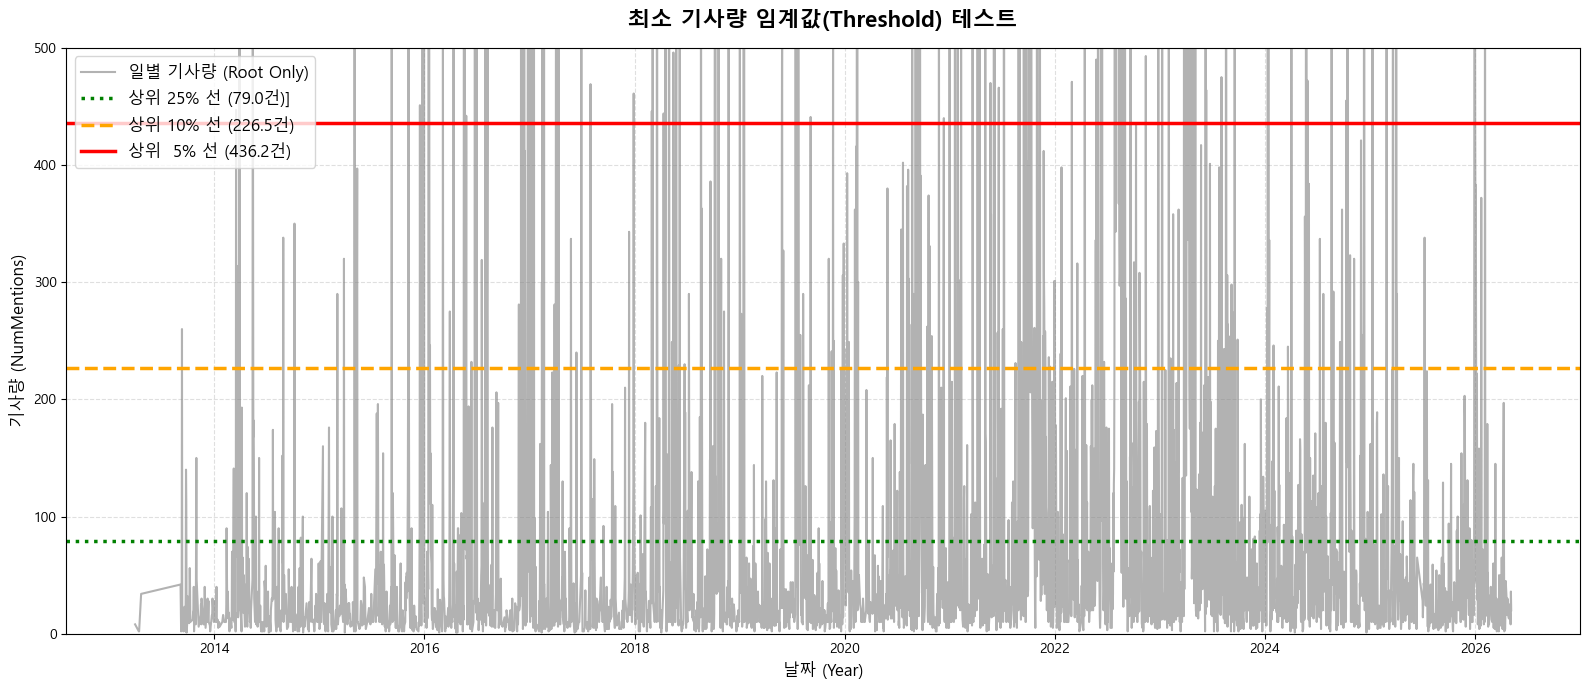

In [27]:
# 1. 0인 날을 제외하고 백분위수 다시 계산 (데이터 준비)
valid_days = daily_root_volume[daily_root_volume['NumMentions'] > 0]['NumMentions']
p75 = valid_days.quantile(0.75)
p90 = valid_days.quantile(0.90)
p95 = valid_days.quantile(0.95)
p99 = valid_days.quantile(0.99)

# 2. 시각화 (전체 기간의 기사량 스파이크)
plt.figure(figsize=(16, 7))

# 일별 총 기사량을 회색 선으로 그리기
plt.plot(daily_root_volume.index, daily_root_volume['NumMentions'], color='gray', alpha=0.6, label='일별 기사량 (Root Only)')

# 3. 테스트할 임계값 가로선(Threshold Lines) 3개 긋기
plt.axhline(y=p75, color='green', linestyle=':', linewidth=2.5, label=f'상위 25% 선 ({p75:.1f}건)]')
plt.axhline(y=p90, color='orange', linestyle='--', linewidth=2.5, label=f'상위 10% 선 ({p90:.1f}건)')
plt.axhline(y=p95, color='red', linestyle='-', linewidth=2.5, label=f'상위  5% 선 ({p95:.1f}건)')

# 그래프 꾸미기
plt.title('최소 기사량 임계값(Threshold) 테스트', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('날짜 (Year)', fontsize=12)
plt.ylabel('기사량 (NumMentions)', fontsize=12)

# 선들이 잘 보이도록 Y축 상한선을 300 정도로 제한
plt.ylim(0, 500) 

plt.legend(loc='upper left', fontsize=12)
plt.grid(True, axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()

# 그래프 출력
plt.show()

In [28]:
# 1. 2023년 데이터만 필터링
df_2023 = daily_root_volume.loc['2023-01-01':'2023-12-31'].copy()

# 2. 빨간선(상위 5% 임계값, 이전 코드의 p95 변수 활용) 돌파 날짜 필터링
spikes_2023 = df_2023[df_2023['NumMentions'] > p95]

# 3. 통계 계산
spike_days = len(spikes_2023)
avg_interval = 365 / spike_days if spike_days > 0 else 0

# 4. 결과 출력
print(f"--- [2023년] 빨간선(상위 5% 임계값: {p95:.1f}건) 돌파 정밀 분석 ---")
print(f"  2023년 총 관측 일수: 365일")
print(f"  빨간선 돌파 일수: {spike_days}일")

if spike_days > 0:
    print(f"  산술적 발생 빈도: 평균 약 {avg_interval:.1f}일에 한 번꼴로 발생 (365일 / {spike_days}일)")
    print("\n--- 2023년 돌파 날짜 상세 목록 (기사량 내림차순) ---")
    display(spikes_2023.sort_values(by='NumMentions', ascending=False))
else:
    print(" 2023년에는 빨간선을 돌파한 날이 없습니다.")

--- [2023년] 빨간선(상위 5% 임계값: 436.2건) 돌파 정밀 분석 ---
  2023년 총 관측 일수: 365일
  빨간선 돌파 일수: 23일
  산술적 발생 빈도: 평균 약 15.9일에 한 번꼴로 발생 (365일 / 23일)

--- 2023년 돌파 날짜 상세 목록 (기사량 내림차순) ---


,NumMentions,MA_7,MA_15,MA_30
SQLDATE,,,,
2023-03-30,2712,796.285714,393.266667,247.033333
2023-04-09,2525,1144.285714,946.266667,493.066667
2023-04-08,2154,802.857143,778.933333,410.633333
2023-06-09,2152,428.428571,242.000000,165.766667
2023-04-12,1994,1578.714286,1211.066667,662.666667
2023-04-10,1903,1383.428571,1017.733333,554.100000
2023-04-21,1588,597.428571,999.600000,810.666667
2023-04-05,1535,801.142857,568.000000,321.866667
2023-03-29,1507,413.714286,214.600000,158.733333


In [30]:
# 1. 노란선(상위 10% 임계값, 이전 코드의 p90 변수 활용) 돌파 날짜 필터링
spikes_2023_yellow = df_2023[df_2023['NumMentions'] > p90]

# 2. 통계 계산
spike_days_yellow = len(spikes_2023_yellow)
avg_interval_yellow = 365 / spike_days_yellow if spike_days_yellow > 0 else 0

# 3. 결과 출력
print(f"--- [2023년] 노란선 (상위 10% 임계값: {p90:.1f}건) 돌파 정밀 분석 ---")
print(f"  2023년 총 관측 일수: 365일")
print(f"  노란선 임계값 돌파 일수: {spike_days_yellow}일")

if spike_days_yellow > 0:
    print(f"  산술적 발생 빈도: 평균 약 {avg_interval_yellow:.1f}일에 한 번꼴로 발생 (365일 / {spike_days_yellow}일)")
    print("\n--- 2023년 노란선 돌파 날짜 상세 목록 (기사량 내림차순) ---")
    display(spikes_2023_yellow.sort_values(by='NumMentions', ascending=False))
else:
    print("  2023년에는 노란선을 돌파한 날이 없습니다.")

--- [2023년] 노란선 (상위 10% 임계값: 226.5건) 돌파 정밀 분석 ---
  2023년 총 관측 일수: 365일
  노란선 임계값 돌파 일수: 47일
  산술적 발생 빈도: 평균 약 7.8일에 한 번꼴로 발생 (365일 / 47일)

--- 2023년 노란선 돌파 날짜 상세 목록 (기사량 내림차순) ---


,NumMentions,MA_7,MA_15,MA_30
SQLDATE,,,,
2023-03-30,2712,796.285714,393.266667,247.033333
2023-04-09,2525,1144.285714,946.266667,493.066667
2023-04-08,2154,802.857143,778.933333,410.633333
2023-06-09,2152,428.428571,242.000000,165.766667
2023-04-12,1994,1578.714286,1211.066667,662.666667
2023-04-10,1903,1383.428571,1017.733333,554.100000
2023-04-21,1588,597.428571,999.600000,810.666667
2023-04-05,1535,801.142857,568.000000,321.866667
2023-03-29,1507,413.714286,214.600000,158.733333


In [32]:
# 1. 노란선(상위 10% 임계값, 이전 코드의 p99 변수 활용) 돌파 날짜 필터링
spikes_2023_yellow = df_2023[df_2023['NumMentions'] > p99]

# 2. 통계 계산
spike_days_yellow = len(spikes_2023_yellow)
avg_interval_yellow = 365 / spike_days_yellow if spike_days_yellow > 0 else 0

# 3. 결과 출력
print(f"--- [2023년] (상위 1% 임계값: {p99:.1f}건) 돌파 정밀 분석 ---")
print(f"  2023년 총 관측 일수: 365일")
print(f"  상위 1% 임계값 돌파 일수: {spike_days_yellow}일")

if spike_days_yellow > 0:
    print(f"  산술적 발생 빈도: 평균 약 {avg_interval_yellow:.1f}일에 한 번꼴로 발생 (365일 / {spike_days_yellow}일)")
    print("\n--- 2023년 상위 1% 임계값 돌파 날짜 상세 목록 (기사량 내림차순) ---")
    display(spikes_2023_yellow.sort_values(by='NumMentions', ascending=False))
else:
    print("  2023년에는 상위 1%를 돌파한 날이 없습니다.")

--- [2023년] (상위 1% 임계값: 1443.4건) 돌파 정밀 분석 ---
  2023년 총 관측 일수: 365일
  상위 1% 임계값 돌파 일수: 9일
  산술적 발생 빈도: 평균 약 40.6일에 한 번꼴로 발생 (365일 / 9일)

--- 2023년 상위 1% 임계값 돌파 날짜 상세 목록 (기사량 내림차순) ---


,NumMentions,MA_7,MA_15,MA_30
SQLDATE,,,,
2023-03-30,2712,796.285714,393.266667,247.033333
2023-04-09,2525,1144.285714,946.266667,493.066667
2023-04-08,2154,802.857143,778.933333,410.633333
2023-06-09,2152,428.428571,242.000000,165.766667
2023-04-12,1994,1578.714286,1211.066667,662.666667
2023-04-10,1903,1383.428571,1017.733333,554.100000
2023-04-21,1588,597.428571,999.600000,810.666667
2023-04-05,1535,801.142857,568.000000,321.866667
2023-03-29,1507,413.714286,214.600000,158.733333


In [19]:
# 1. 일일 총 기사량이 200건 이상 300건 미만인 '경계선(Borderline)' 날짜 추출
borderline_mask = (daily_root_volume['NumMentions'] >= 200) & (daily_root_volume['NumMentions'] < 300)
borderline_days = daily_root_volume[borderline_mask].index

# 2. 원본 데이터(df_root)에서 해당 날짜 기사만 필터링
borderline_articles = df_root[df_root['SQLDATE'].isin(borderline_days)]

# 3. 샘플링 (데이터가 10개 미만일 수 있으므로 예외 처리 추가)
sample_size = min(10, len(borderline_articles))

if sample_size > 0:
    sample_borderline = borderline_articles.sample(n=sample_size, random_state=42)
    sample_borderline = sample_borderline.sort_values(by='SQLDATE')

    # 4. 결과 출력
    print("--- 🔍 [경계선 검증] 기사량 200~299건 뉴스 원문 샘플 ---")
    print(f"✔️ 조건에 해당하는 총 기사 수: {len(borderline_articles):,}건\n")

    for idx, row in sample_borderline.iterrows():
        # 날짜 포맷팅 안전하게 처리
        date_str = row['SQLDATE'].strftime('%Y-%m-%d') if pd.api.types.is_datetime64_any_dtype(row['SQLDATE']) else str(row['SQLDATE'])
        
        event_code = row['EventCode']
        mentions = row['NumMentions']
        url = row['SOURCEURL']
        
        print(f"[{date_str}] (기사량: {mentions}건) | CAMEO: {event_code}")
        print(f"🔗 URL: {url}\n")
else:
    print("해당 기사량(200~300건 미만) 구간에 속하는 데이터가 없습니다.")

--- 🔍 [경계선 검증] 기사량 200~299건 뉴스 원문 샘플 ---
✔️ 조건에 해당하는 총 기사 수: 2,365건

[2018-06-24 00:00:00] (기사량: 34건) | CAMEO: 154
🔗 URL: http://www.newsradioklbj.com/news/politics/top-political-news/mattis-visit-china-taiwan-s-china-sea-tensions-rise

[2019-11-17 00:00:00] (기사량: 2건) | CAMEO: 141
🔗 URL: https://www.aljazeera.com/programmes/listeningpost/2019/11/taiwan-push-red-media-191116110248601.html

[2020-08-13 00:00:00] (기사량: 2건) | CAMEO: 190
🔗 URL: https://www.taipeitimes.com/News/front/archives/2020/08/14/2003741653

[2021-08-17 00:00:00] (기사량: 2건) | CAMEO: 150
🔗 URL: https://www.thehindu.com/news/international/china-stages-assault-drills-near-taiwan/article35964394.ece

[2021-10-13 00:00:00] (기사량: 6건) | CAMEO: 130
🔗 URL: https://www.dailystar.co.uk/news/world-news/ww3-fears-china-will-spark-25209034

[2022-01-21 00:00:00] (기사량: 14건) | CAMEO: 150
🔗 URL: https://www.dailymail.co.uk/news/article-10427003/Biden-seek-support-Japanese-PM-Kishida-Fumio-Ukraine.html

[2022-03-09 00:00:00] (기사량: 2건) |

In [20]:
# 1. 일일 총 기사량이 200건 이상 300건 미만인 날짜(Days) 추출
borderline_mask = (daily_root_volume['NumMentions'] >= 200) & (daily_root_volume['NumMentions'] < 300)
borderline_days = daily_root_volume[borderline_mask].index

# 2. 기사가 아니라 '날짜'를 기준으로 무작위 5일만 샘플링
sample_days = pd.Series(borderline_days).sample(n=min(5, len(borderline_days)), random_state=42)

print("--- 🔍 [경계선 검증] 하루 총 기사량 200~299건인 날의 '당일 1위 기사' 샘플 ---")

# 3. 뽑힌 5일(날짜)에 대해 반복문 실행
for day in sample_days.sort_values():
    
    # 해당 날짜의 전체 기사량 확인
    daily_total = daily_root_volume.loc[day, 'NumMentions']
    date_str = day.strftime('%Y-%m-%d') if pd.api.types.is_datetime64_any_dtype(day) else str(day)
    
    # ★ 핵심: 해당 날짜의 원본 기사들 중 '가장 많이 언급된(NumMentions 최고점)' 기사 1개만 추출
    articles_on_day = df_root[df_root['SQLDATE'] == day]
    top_article = articles_on_day.sort_values(by='NumMentions', ascending=False).iloc[0]
    
    event_code = top_article['EventCode']
    mentions = top_article['NumMentions']
    url = top_article['SOURCEURL']
    
    print(f"[{date_str}] (해당 일자 전체 총 기사량: {daily_total:.0f}건)")
    print(f" ↳ 🏆 당일 1위 핵심 기사 (개별 언급량: {mentions}건) | CAMEO: {event_code}")
    print(f" ↳ 🔗 URL: {url}\n")

--- 🔍 [경계선 검증] 하루 총 기사량 200~299건인 날의 '당일 1위 기사' 샘플 ---
[2017-04-02 00:00:00] (해당 일자 전체 총 기사량: 210건)
 ↳ 🏆 당일 1위 핵심 기사 (개별 언급량: 200건) | CAMEO: 190
 ↳ 🔗 URL: http://forums.asiaone.com/showthread.php?s=353d91aa1bf9c4055f402d92a621ce28&t=92495

[2020-10-14 00:00:00] (해당 일자 전체 총 기사량: 262건)
 ↳ 🏆 당일 1위 핵심 기사 (개별 언급량: 105건) | CAMEO: 130
 ↳ 🔗 URL: http://www.gdnonline.com/Details/874664

[2021-11-29 00:00:00] (해당 일자 전체 총 기사량: 221건)
 ↳ 🏆 당일 1위 핵심 기사 (개별 언급량: 39건) | CAMEO: 195
 ↳ 🔗 URL: https://wtvbam.com/2021/11/29/taiwan-says-china-military-trying-to-wear-it-out-but-it-can-respond/

[2022-09-05 00:00:00] (해당 일자 전체 총 기사량: 286건)
 ↳ 🏆 당일 1위 핵심 기사 (개별 언급량: 185건) | CAMEO: 141
 ↳ 🔗 URL: https://www.rfi.fr/en/international-news/20220905-solomon-islands-pm-says-to-lift-ban-on-foreign-navy-ships-soon

[2024-10-17 00:00:00] (해당 일자 전체 총 기사량: 248건)
 ↳ 🏆 당일 1위 핵심 기사 (개별 언급량: 146건) | CAMEO: 130
 ↳ 🔗 URL: https://www.yahoo.com/news/china-toughens-taiwan-stance-over-014734908.html



C:\Users\Jua\AppData\Local\Temp\ipykernel_48400\3135532509.py:31: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\Jua\.conda\envs\sia_wevengers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


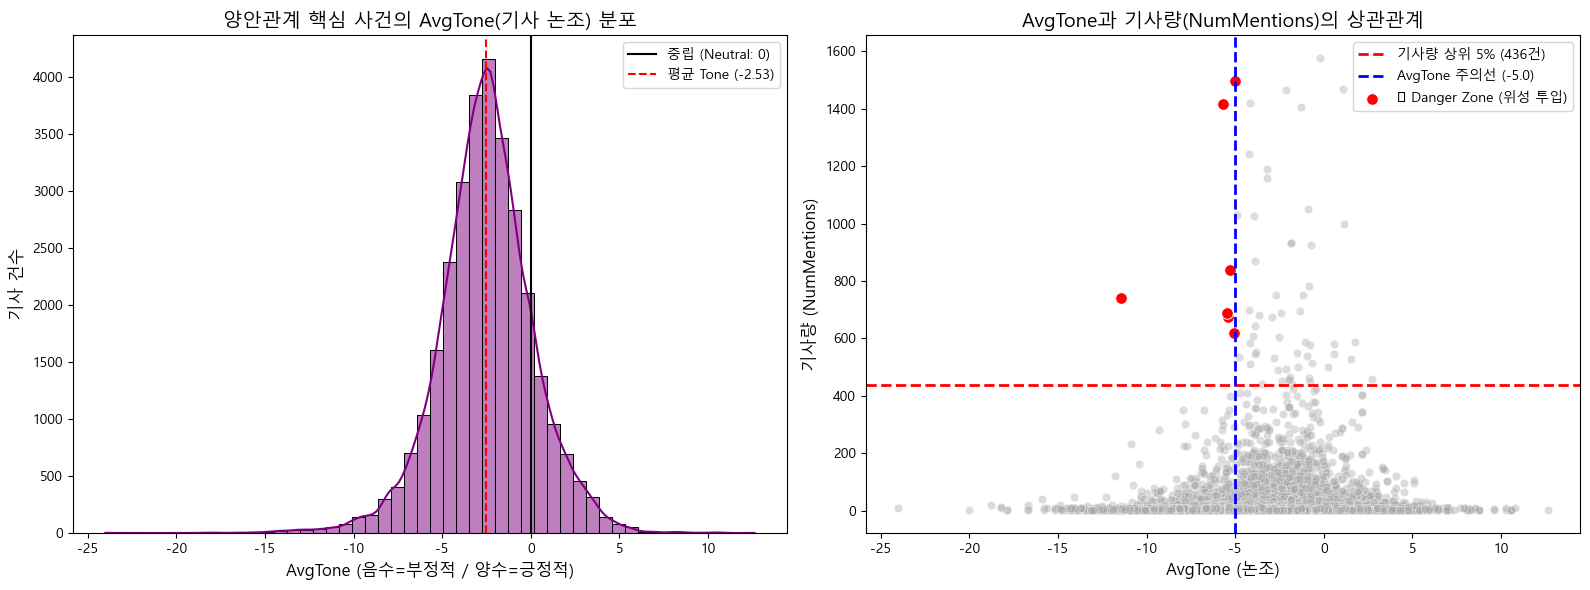

In [21]:
# 1. 화면 분할 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- [그래프 1] AvgTone 분포도 (Density Plot) ---
sns.histplot(df_root['AvgTone'], bins=50, kde=True, color='purple', ax=axes[0])
axes[0].axvline(0, color='black', linestyle='-', linewidth=1.5, label='중립 (Neutral: 0)')
axes[0].axvline(df_root['AvgTone'].mean(), color='red', linestyle='--', label=f"평균 Tone ({df_root['AvgTone'].mean():.2f})")

axes[0].set_title('양안관계 핵심 사건의 AvgTone(기사 논조) 분포', fontsize=14)
axes[0].set_xlabel('AvgTone (음수=부정적 / 양수=긍정적)', fontsize=12)
axes[0].set_ylabel('기사 건수', fontsize=12)
axes[0].legend()

# --- [그래프 2] AvgTone vs NumMentions 산점도 (Quadrant Analysis) ---
sns.scatterplot(data=df_root, x='AvgTone', y='NumMentions', alpha=0.4, color='darkgray', ax=axes[1])

# 기준선 긋기 (기사량 상위 5% & AvgTone -5.0)
axes[1].axhline(p95, color='red', linestyle='--', linewidth=2, label=f'기사량 상위 5% ({p95:.0f}건)')
axes[1].axvline(-5.0, color='blue', linestyle='--', linewidth=2, label='AvgTone 주의선 (-5.0)')

# '진짜 위기' 영역(Danger Zone) 강조 (왼쪽 위 사분면)
# 조건: 기사량이 상위 5% 이상이면서, 논조가 -5.0 이하로 매우 부정적인 기사들
danger_zone = df_root[(df_root['NumMentions'] >= p95) & (df_root['AvgTone'] <= -5.0)]
sns.scatterplot(data=danger_zone, x='AvgTone', y='NumMentions', color='red', s=70, ax=axes[1], label='🚨 Danger Zone (위성 투입)')

axes[1].set_title('AvgTone과 기사량(NumMentions)의 상관관계', fontsize=14)
axes[1].set_xlabel('AvgTone (논조)', fontsize=12)
axes[1].set_ylabel('기사량 (NumMentions)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
print("--- 상위 0.1% 6대 사건 원문 확인 ---")

# 아까 만든 danger_zone 데이터프레임을 기사량(NumMentions) 내림차순으로 정렬
top_6_crises = danger_zone.sort_values(by='NumMentions', ascending=False)

for rank, (idx, row) in enumerate(top_6_crises.iterrows(), 1):
    # 날짜 포맷팅 안전 처리
    date_str = row['SQLDATE'].strftime('%Y-%m-%d') if pd.api.types.is_datetime64_any_dtype(row['SQLDATE']) else str(row['SQLDATE'])
    
    mentions = row['NumMentions']
    tone = row['AvgTone']
    url = row['SOURCEURL']
    
    print(f"[Top {rank}] {date_str} | 기사량: {mentions:.0f}건 | 논조(Tone): {tone:.2f}")
    print(f"🔗 원문 링크: {url}\n")

--- 상위 0.1% 6대 사건 원문 확인 ---
[Top 1] 2020-02-14 00:00:00 | 기사량: 1498건 | 논조(Tone): -5.03
🔗 원문 링크: https://tucson.com/news/world/virus-infects-more-than-health-workers-in-china-die/article_4d12ac71-39ec-54e1-85bd-cbc6bcd7add5.html

[Top 2] 2021-11-01 00:00:00 | 기사량: 1418건 | 논조(Tone): -5.70
🔗 원문 링크: https://www.sanantoniopost.com/news/271625612/sky-pods-to-carry-commuters-on-cable-in-air-being-tested-in-uae

[Top 3] 2021-10-03 00:00:00 | 기사량: 840건 | 논조(Tone): -5.28
🔗 원문 링크: https://www.mdjonline.com/tribune/china-continues-taiwan-flybys-on-second-day-with-39-more-jets/article_a44624e9-97e5-50df-9b60-2d44b77f83d4.html

[Top 4] 2017-01-05 00:00:00 | 기사량: 740건 | 논조(Tone): -11.44
🔗 원문 링크: http://hosted.ap.org/dynamic/stories/A/AS_TAIWAN_CHINA_FRAUD_SUSPECTS?SITE=AP&SECTION=HOME&TEMPLATE=DEFAULT&CTIME=2017-01-04-23-11-22

[Top 5] 2019-07-24 00:00:00 | 기사량: 690건 | 논조(Tone): -5.48
🔗 원문 링크: https://www.borehamwoodtimes.co.uk/news/national/17790707.china-will-not-rule-using-force-reunify-taiwan/

[

In [23]:
print("--- 블랙리스트 및 찌라시 필터링 적용 중... ---")

# 1. URL 기반 블랙리스트 키워드 (질병, 선거, 경제 등 군사 위협과 무관한 단어)
# (GDELT는 URL에 기사의 핵심 키워드가 들어가는 경우가 많아 URL 필터링이 효과적입니다)
blacklist_words = ['virus', 'covid', 'pandemic', 'disease', 'vaccine', 'election', 'trade', 'economy']

# 2. 신뢰할 수 없는 출처 (포럼, 블로그 형식)
junk_sources = ['forum', 'showthread.php', 'blog', 'wordpress']

# 소문자로 변환한 URL 컬럼 생성 (검색을 쉽게 하기 위함)
danger_zone['url_lower'] = danger_zone['SOURCEURL'].str.lower()

# 3. 필터링 로직 적용 (블랙리스트 단어가 URL에 '없는' 것만 남김)
# 3-1. 키워드 블랙리스트 제거
for word in blacklist_words:
    danger_zone = danger_zone[~danger_zone['url_lower'].str.contains(word, na=False)]

# 3-2. 찌라시/포럼 사이트 제거
for junk in junk_sources:
    danger_zone = danger_zone[~danger_zone['url_lower'].str.contains(junk, na=False)]

# 임시로 만든 소문자 URL 컬럼 삭제
danger_zone = danger_zone.drop(columns=['url_lower'])


# --- 🚨 다시 확인하는 상위 6대 사건 ---
print("\n--- 진짜 군사적 위기 Top 사건 원문 확인 ---")

top_crises_clean = danger_zone.sort_values(by='NumMentions', ascending=False).head(10) # 넉넉히 10개 확인

for rank, (idx, row) in enumerate(top_crises_clean.iterrows(), 1):
    date_str = row['SQLDATE'].strftime('%Y-%m-%d') if pd.api.types.is_datetime64_any_dtype(row['SQLDATE']) else str(row['SQLDATE'])
    
    mentions = row['NumMentions']
    tone = row['AvgTone']
    url = row['SOURCEURL']
    
    print(f"[Top {rank}] {date_str} | 기사량: {mentions:.0f}건 | 논조(Tone): {tone:.2f}")
    print(f"🔗 원문 링크: {url}\n")

--- 블랙리스트 및 찌라시 필터링 적용 중... ---

--- 진짜 군사적 위기 Top 사건 원문 확인 ---
[Top 1] 2021-11-01 00:00:00 | 기사량: 1418건 | 논조(Tone): -5.70
🔗 원문 링크: https://www.sanantoniopost.com/news/271625612/sky-pods-to-carry-commuters-on-cable-in-air-being-tested-in-uae

[Top 2] 2021-10-03 00:00:00 | 기사량: 840건 | 논조(Tone): -5.28
🔗 원문 링크: https://www.mdjonline.com/tribune/china-continues-taiwan-flybys-on-second-day-with-39-more-jets/article_a44624e9-97e5-50df-9b60-2d44b77f83d4.html

[Top 3] 2017-01-05 00:00:00 | 기사량: 740건 | 논조(Tone): -11.44
🔗 원문 링크: http://hosted.ap.org/dynamic/stories/A/AS_TAIWAN_CHINA_FRAUD_SUSPECTS?SITE=AP&SECTION=HOME&TEMPLATE=DEFAULT&CTIME=2017-01-04-23-11-22

[Top 4] 2019-07-24 00:00:00 | 기사량: 690건 | 논조(Tone): -5.48
🔗 원문 링크: https://www.borehamwoodtimes.co.uk/news/national/17790707.china-will-not-rule-using-force-reunify-taiwan/

[Top 5] 2023-04-26 00:00:00 | 기사량: 676건 | 논조(Tone): -5.43
🔗 원문 링크: https://www.islingtongazette.co.uk/news/national/23480972.isolating-china-sign-weakness-says-clever

C:\Users\Jua\AppData\Local\Temp\ipykernel_48400\1309676123.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  danger_zone['url_lower'] = danger_zone['SOURCEURL'].str.lower()
